
 Ce librarii folosim si de ce
Pentru curatarea si aranjarea datelor ne bazam pe clasicele `pandas` si `numpy`
Graficele (cum sunt curba ROC) le desenam cu ajutorul `matplotlib.pyplot`
Din `scikit-learn` luam instrumentele de preprocesare (`StandardScaler`, `train_test_split`) si modelele pentru clasificarea binara: `LogisticRegression`, `DecisionTreeClassifier` si `RandomForestClassifier`, am adaugat si `LinearRegression` pentru un scenariu diferit de estimare 
 Evaluarea o facem pe baza de acuratete, matricea de confuzie, raportul de clasificare, punctele pentru curba ROC, plus MAE, MAPE, MSE

Decizii luate la preprocesare si ipoteze asumate
1. Curatarea datelor : Coloana `Total Charges` avea cateva spatii goale sau formate ciudate ,am fortat transformarea lor in numere, iar in locul bucatilor lipsa am pus `0` ca sa nu blocam calculele matematice din algoritmi
2. Transformarea textului in numere : Pe coloana tinta (`Churn Label`) am mapat simplu `Yes` cu 1 si `No` cu 0. Pentru restul coloanelor cu text (`Contract` si `Premium Tech Support`), am folosit metoda One-Hot Encoding cu optiunea `drop_first=True`. Asta elimina coloanele redundante si previne problemele de corelare perfecta intre variabile.
3. Impartirea bazei de date: Am separat datele in 80% pentru antrenare si 20% pentru test. Am adaugat parametrul `stratify=y` ca sa fim siguri ca distributia clientilor care pleaca (in jur de 26%) ramane identica in ambele seturi, evitand o evaluare dezechilibrata.
4. Scalarea datelor: Vechimea are valori mici (luni), in timp ce costurile totale sunt de ordinul miilor. Ca sa nu inducem in eroare modelele liniare, am adus toate cifrele pe aceeasi scara cu `StandardScaler` am folosit `fit_transform` pe datele de antrenament (ca modelul sa invete media de acolo) si doar `transform` pe datele de test, pastrandu-le complet secrete pt a evita data leakage

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("telco.csv")
# errors='coerce' transforma orice text ciudat sau spatiu gol in NaN, apoi punem 0
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")
df["Total Charges"] = df["Total Charges"].fillna(0)
df["Churn Label"] = df["Churn Label"].map({"Yes": 1, "No": 0})

coloane_selectate = [
    "Tenure in Months",
    "Monthly Charge",
    "Total Charges",
    "Contract",
    "Premium Tech Support",
    "Churn Label",
]
df = df[coloane_selectate]
X = df.drop(columns=["Churn Label"])#info baza carora modelul va invata
y = df["Churn Label"]#vrem ca modelul sa le prezica

X_encoded = pd.get_dummies(
    X, columns=["Contract", "Premium Tech Support"], drop_first=True
)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y

)

scaler = StandardScaler()
#ia fiecare valoare numerica, scade media coloanei si o imparte la deviatia standard/gauss
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)

print("REZULTATE LOGISTIC REGRESSION ")
print(f"Acuratete generala: {accuracy_score(y_test, y_pred_log):.4f}\n")

print("Matricea de Confuzie (Confusion Matrix):")
print(confusion_matrix(y_test, y_pred_log))

print("Raportul de Clasificare:")
print(classification_report(y_test, y_pred_log))

REZULTATE LOGISTIC REGRESSION 
Acuratete generala: 0.7935

Matricea de Confuzie (Confusion Matrix):
[[920 115]
 [176 198]]
Raportul de Clasificare:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.53      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409



 regresie logistica si  clasificare
 acest model face de fapt clasificare. El calculeaza o probabilitate intre 0 si 1 folosind o functie matematica numita sigmoida. Scikit-learn aplica un prag standard de 0.5: daca un client are o probabilitate de plecare de peste 50%, primeste eticheta 1 (risc de churn), altfel primeste 0 (ramane in companie).

-Acuratetea: Modelul nimereste eticheta corecta pentru aproape 8 din 10 clienti.
-Matricea de confuzie: Modelul recunoaste frumos clientii stabili (920 de cazuri numite True Negatives) si prinde corect 198 de clienti care pleaca (True Positives). Totusi, da 115 alarme false (False Positives) si rateaza 176 de clienti care pleaca fara ca noi sa observam (False Negatives).
-Recall pe clasa de churn (0.53 / 53%): Aceasta este o mica problema pentru business. Modelul reuseste sa intercepteze doar putin peste jumatate din totalul celor care vor rezilia contractul. Restul de 47% ne scapa printre degete daca ne bazam doar pe pragul standard.

In [2]:
from sklearn.tree import DecisionTreeClassifier
dt_overfitting = DecisionTreeClassifier(random_state=42)
dt_overfitting.fit(X_train_scaled, y_train)#anrenam pe train
y_pred_train_dt = dt_overfitting.predict(X_train_scaled)
y_pred_test_dt = dt_overfitting.predict(X_test_scaled)
acc_train = accuracy_score(y_train, y_pred_train_dt)
acc_test = accuracy_score(y_test, y_pred_test_dt)

print(" OVERFITTING (DECISION TREE)")
print(f"Acuratete pe datele de ANTRENARE (Train): {acc_train:.4f} ({acc_train*100:.1f}%)")
print(f"Acuratete pe datele de TESTARE (Test):    {acc_test:.4f} ({acc_test*100:.1f}%)")

if acc_train > acc_test + 0.1:
    print(" OVERFITTING!")
    print("A invatat pe de rost datele de train, dar nu generalizeaza bine pe date noi.")

 OVERFITTING (DECISION TREE)
Acuratete pe datele de ANTRENARE (Train): 0.9906 (99.1%)
Acuratete pe datele de TESTARE (Test):    0.7275 (72.7%)
 OVERFITTING!
A invatat pe de rost datele de train, dar nu generalizeaza bine pe date noi.


provocarea tehnica: overfitting

experimentul cu arborele de decizie lasat liber
Ca sa intelegem riscul modelelor prea complexe, am antrenat un `DecisionTreeClassifier` fara sa punem nicio limita de adancime (`max_depth=None`). In acest scenariu, algoritmul continua sa puna intrebari succesive pana cand izoleaza aproape fiecare client in parte din setul de antrenare.

Acuratetea(Train) a iesit de 99.10%:modelul a invatat pe de rost 
Acuratetea(Test) a scazut la 72.75%: Cand a dat de intrebari noi, modelul s-a incurcat in regulile lui prea specifice si a dat rateuri. Aceasta diferenta uriasa de performanta este definitia clara a fenomenului de overfitting  

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

dt_regularizat = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_regularizat.fit(X_train_scaled, y_train)
y_pred_test_dt_reg = dt_regularizat.predict(X_test_scaled)
acc_test_dt_reg = accuracy_score(y_test, y_pred_test_dt_reg)

random_forest = RandomForestClassifier(
    n_estimators=100, max_depth=5, random_state=42
)
random_forest.fit(X_train_scaled, y_train)
y_pred_test_rf = random_forest.predict(X_test_scaled)
acc_test_rf = accuracy_score(y_test, y_pred_test_rf)

print(" REZULTATE DUPA REPARARE ")
print(
    f"Acuratete Decision Tree  (Overfitting): {acc_test:.4f} ({acc_test*100:.1f}%)"
)
print(
    f"Acuratete Decision Tree REGULARIZAT (max_depth=4): {acc_test_dt_reg:.4f} ({acc_test_dt_reg*100:.1f}%)"
)
print(f"Acuratete RANDOM FOREST:                    {acc_test_rf:.4f} ({acc_test_rf*100:.1f}%)")

# Verificam daca regularizarea a functionat
if acc_test_dt_reg > acc_test:
    print(
        f"Succes! Performanta pe datele de Test a crescut cu {(acc_test_dt_reg - acc_test)*100:.2f}%!"
    )

 REZULTATE DUPA REPARARE 
Acuratete Decision Tree  (Overfitting): 0.7275 (72.7%)
Acuratete Decision Tree REGULARIZAT (max_depth=4): 0.7857 (78.6%)
Acuratete RANDOM FOREST:                    0.7956 (79.6%)
Succes! Performanta pe datele de Test a crescut cu 5.82%!


Rezolvarea overfitting-ului: regularizare si modele de ansamblu

 solutia 1: taierea arborelui 
Prima metoda a fost sa-i punem o limita arborelui. Prin setarea parametrului `max_depth=4`, i-am interzis sa puna mai mult de 4 intrebari consecutive in jos. Fortat sa ramana simplu, algoritmul a trebuit sa caute doar regulile generale importante (cum ar fi tipul de contract sau vechimea)
Rezultat: Acuratetea pe test a urcat instant la 78.57%, reparand prabusirea anterioara.

solutia 2: Random Forest
arbori independenti (`n_estimators=100`). Fiecare arbore se antreneaza pe o bucatica aleatoare din date si din coloane. Cand vine un client nou, toti cei 100 de arbori voteaza, iar decizia finala se ia prin majoritate. Erorile individuale se anuleaza reciproc.
Rezultat: Obtinem cea mai stabila performanta pe setul de test, cu o acuratete de 79.56%.

=== LIVRABIL: MODEL COMPARISON TABLE ===
                      Model Accuracy (Test) ROC-AUC Score
        Logistic Regression          0.7935        0.8518
Decision Tree (Regularizat)          0.7857        0.8306
              Random Forest          0.7956        0.8533
------------------------------------------------------------


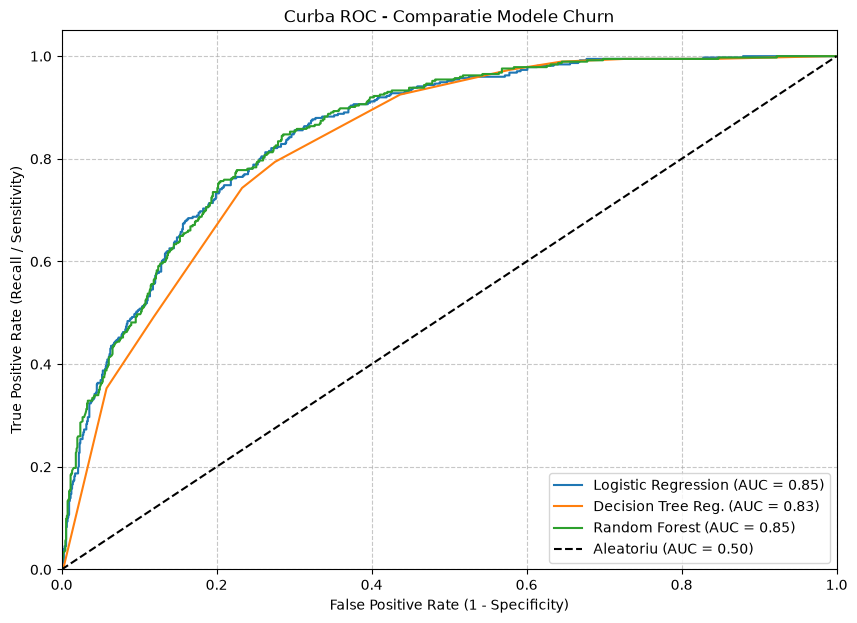

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import roc_auc_score, roc_curve

#  curba ROC pentru cele 3 modele bune
y_proba_log = log_reg.predict_proba(X_test_scaled)[:, 1]
y_proba_dt_reg = dt_regularizat.predict_proba(X_test_scaled)[:, 1]
y_proba_rf = random_forest.predict_proba(X_test_scaled)[:, 1]

# Calculam scorurile ROC-AUC efective
auc_log = roc_auc_score(y_test, y_proba_log)
auc_dt_reg = roc_auc_score(y_test, y_proba_dt_reg)
auc_rf = roc_auc_score(y_test, y_proba_rf)

# 2. Generam tabelul de comparatie cerut in document
print("=== LIVRABIL: MODEL COMPARISON TABLE ===")
comparison_data = {
    "Model": ["Logistic Regression", "Decision Tree (Regularizat)", "Random Forest"],
    "Accuracy (Test)": [
        f"{accuracy_score(y_test, y_pred_log):.4f}",
        f"{accuracy_score(y_test, y_pred_test_dt_reg):.4f}",
        f"{accuracy_score(y_test, y_pred_test_rf):.4f}",
    ],
    "ROC-AUC Score": [f"{auc_log:.4f}", f"{auc_dt_reg:.4f}", f"{auc_rf:.4f}"],
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))
print("-" * 60)

# 3. Desenam Curba ROC pentru cele 3 modele
plt.figure(figsize=(10, 7))

# Calculam punctele pentru fiecare model
fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_log)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt_reg)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

# Plotam liniile in grafic
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {auc_log:.2f})")
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree Reg. (AUC = {auc_dt_reg:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.2f})")

# Linia de referinta pentru un model complet aleatoriu
plt.plot([0, 1], [0, 1], "k--", label="Aleatoriu (AUC = 0.50)")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Recall / Sensitivity)")
plt.title("Curba ROC - Comparatie Modele Churn")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

tabelul comparativ si curba ROC

Acuratetea ne poate pacali uneori. Curba ROC ne arata cum se comporta modelele la toate pragurile posibile de decizie, punand in balanta rata succeselor si rata alarmelor false . AUC masoara spatiul de sub aceasta curba. Un model complet aleatoriu  are un AUC de 0.50, in timp ce un model ideal are 1.00

Atat Regresia Logistica, cat si Random Forest obtin un scor de `AUC = 0.85`,capabil sa separe eficient clientii stabili de cei cu risc de plecare
Arborele Regularizat , cu un `AUC = 0.83`

Decizia de business
Desi impart acelasi scor AUC (0.85), alegem ca model final Random Forest. Acesta bifeaza cea mai ridicata acuratete generala de pe test 79.56% si ofera o stabilitate mult mai buna la aparitia unor clienti noi

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
#regresia liniara
#pentru regresie avem nevoie de un target continuu
X_reg = df.drop(columns=['Monthly Charge', 'Contract', 'Premium Tech Support'])
y_reg = df['Monthly Charge']
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
lin_reg = LinearRegression()
lin_reg.fit(X_train_r, y_train_r)
y_pred_reg = lin_reg.predict(X_test_r)

print("=== REZULTATE METRICE REGRESIE ===")
print(f"MAE (Mean Absolute Error): {mean_absolute_error(y_test_r, y_pred_reg):.4f}")
print(f"MAPE (Mean Absolute Percentage Error): {mean_absolute_percentage_error(y_test_r, y_pred_reg):.4f}")
print(f"MSE (Mean Squared Error): {mean_squared_error(y_reg_test if 'y_reg_test' in locals() else y_test_r, y_pred_reg):.4f}")



=== REZULTATE METRICE REGRESIE ===
MAE (Mean Absolute Error): 12.9031
MAPE (Mean Absolute Percentage Error): 0.3303
MSE (Mean Squared Error): 268.0026


regresie liniara pentru estimarea costurilor lunare

 clasificare vs regresie
Pana acum am facut doar clasificare. In aceasta ultima celula trecem la o problema de regresie, unde variabila tinta (`Monthly Charge`) este un numar continuu. Aici masuram distanta fizica dintre ce a estimat modelul si ce plateste clientul in realitate 

MAE (Mean Absolute Error) = 12.9031: In medie, modelul de regresie rateaza valoarea reala a facturii cu aproximativ 12.90 unitati monetare
MAPE (Mean Absolute Percentage Error) = 0.3303 (33.03%):. Predictiile noastre deviaza in medie cu 33% fata de realitate. 

MSE (Mean Squared Error) = 268.0026: Aceasta metrica ridica erorile la patrat,valoarea destul de ridicata ne avertizeaza ca avem in baza de date cateva cazuri izolate (outliers) cu facturi foarte mari sau neobisnuite, unde modelul a dat erori mai mari de estimare.